# setup


In [1]:
!pip uninstall -y jax jaxlib

!pip install -U numpy==1.24.4 pandas torch
!pip install -U transformers==4.33.3
!pip install -U rdkit-pypi==2022.9.5 mordred[full] padelpy

!pip install botorch


Found existing installation: jax 0.5.2
Uninstalling jax-0.5.2:
  Successfully uninstalled jax-0.5.2
Found existing installation: jaxlib 0.5.1
Uninstalling jaxlib-0.5.1:
  Successfully uninstalled jaxlib-0.5.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 81.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.2/821.2 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 6.5 MB/s eta 0:00:

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.9/119.9 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 114.2 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.21.1
    Uninstalling tokenizers-0.21.1:
      Successfully uninstalled tokenizers-0.21.1
  Attempting uninstall: transformers
    Found existing installation: transformers 4.52.4
    Uninstalling transformers-4.52.4:
      Successfully uninstalled transformers-4.52.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 4.1.0 requires transformers<5.0.0,>=4.41.0, but you have transformers 4.33.3 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.8/128.8 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... 

In [1]:
!pip install git+https://github.com/jensengroup/UQ_validation_methods


  Cloning https://github.com/jensengroup/UQ_validation_methods to /tmp/pip-req-build-e1m4l0sa
  Running command git clone --filter=blob:none --quiet https://github.com/jensengroup/UQ_validation_methods /tmp/pip-req-build-e1m4l0sa
  Resolved https://github.com/jensengroup/UQ_validation_methods to commit 984730d26b9ddd5f900ff9fe390363686632d4a2
  Preparing metadata (setup.py) ... done
  Created wheel for UQ_validation_methods: filename=UQ_validation_methods-0.0.0-py3-none-any.whl size=4848 sha256=70a78ebdda60c64b44182a66e9d395188b02efed5e3d7ff73b9e28781bad68f6
  Stored in directory: /tmp/pip-ephem-wheel-cache-6xxtd1rl/wheels/90/b4/6c/a81a9b55bf789b1a05ef96e1973c7c1f4b8c4ce0ad76ddf399
Successfully built UQ_validation_methods


In [2]:
import numpy as np
import pandas as pd
import torch
from rdkit import Chem
from mordred import Calculator, descriptors
from padelpy import from_smiles
from transformers import AutoTokenizer, AutoModel

import tqdm
import pickle

In [3]:
from google.colab import drive
drive.mount('/content/drive')

%cd '/content/drive/MyDrive/Colab Notebooks/moldais/'



Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/moldais


In [4]:
import warnings
warnings.filterwarnings('ignore')

from rdkit.Chem import AllChem
from rdkit import Chem
from rdkit.Chem import AllChem
from padelpy import padeldescriptor
import pandas as pd
import tempfile, os


import os
import xml.etree.ElementTree as ET
from padelpy import from_smiles
import pandas as pd
import xml.etree.ElementTree as ET
from padelpy import from_smiles
import pandas as pd
import re
import pandas as pd
from padelpy import padeldescriptor
import tempfile, os



# calulators

In [5]:


def compute_mordred(smiles):
    calc = Calculator(descriptors, ignore_3D=True)
    mols = [Chem.MolFromSmiles(smi) for smi in smiles]
    df = calc.pandas(mols)
    df = df.dropna(axis=1)  # Remove descriptors with NaNs
    df_numeric = df.select_dtypes(include=['number'])
    return df_numeric




def compute_padel(smiles,
                        xml=None,        # optional custom XML
                        threads=1,
                        maxruntime=600000):

  # 1) Build & sanitize a 2D RDKit mol
    m = Chem.MolFromSmiles(smiles)
    m = Chem.AddHs(m)                          # explicit Hs
    Chem.SanitizeMol(m, Chem.SANITIZE_ALL)     # valence, kekulize, aromaticity
    AllChem.Compute2DCoords(m)                 # assign 2D coords

    # 2) Write it to an SDF
    tf = tempfile.NamedTemporaryFile(suffix=".sdf", delete=False)
    writer = Chem.SDWriter(tf.name)
    writer.write(m)
    writer.close()

    # 3) Call padeldescriptor on the SDF
    out_csv = tf.name + ".csv"
    padeldescriptor(
        mol_dir=tf.name,
        d_file=out_csv,
        fingerprints=False,
        d_2d=True,
        d_3d=False,
        threads=threads,
        maxruntime=maxruntime,
        headless=True
    )

    # 4) Read & clean up
    df = pd.read_csv(out_csv, index_col=0)
    os.unlink(tf.name); os.unlink(out_csv)
    return df.dropna(axis=1)


from transformers import AutoTokenizer, AutoModel
import torch

def compute_chemberta(smiles):
    tokenizer = AutoTokenizer.from_pretrained(
        "seyonec/ChemBERTa-zinc-base-v1", trust_remote_code=True
    )
    model = AutoModel.from_pretrained(
        "seyonec/ChemBERTa-zinc-base-v1", trust_remote_code=True
    )

    model.eval()
    with torch.no_grad():
        features = []
        for smi in smiles:
            tokens = tokenizer(smi, return_tensors="pt", truncation=True, padding=True)
            outputs = model(**tokens)
            cls_embedding = outputs.last_hidden_state[:, 0, :]  # CLS token
            features.append(cls_embedding.squeeze().numpy())

    return np.vstack(features)



# ---------------------- Main Interface ----------------------

def compute_features(smiles):
    return {
        "mordred": compute_mordred(smiles),
        "padel": compute_padel(smiles),
        "chemberta": compute_chemberta(smiles),
        #"deepchem": compute_deepchem(smiles),
    }

# ---------------------- Example Usage ----------------------

# smiles = ["CCO", "CCN", "c1ccccc1", "O=C=O"]
# features = compute_features(smiles)
# for name, mat in features.items():
#     print(f"{name}: shape = {mat.shape}")


#load data and compute features


In [15]:
if 0 : #features already computed
  problems = ['cep']#,'dG']

  for prob in problems:

    print(prob, '....')


    if prob == 'dG' :
      key = 'Gsolv'
    else:
      key = 'y1'

    df = pd.read_csv(f'{prob}.csv').drop(columns=['Unnamed: 0'])[:300]


    np.random.seed(0)
    train_samples = np.random.choice(df.index, 40, replace=False)
    train_mask = df.index.isin(train_samples)

    y_train = df[key][train_mask].to_list()
    y_test = df[key][~train_mask].to_list()

    #make training features
    smiles = df['SMILES'][train_mask].to_list()
    i = 0
    for s in tqdm.tqdm(smiles):
        if i == 0 :
          X_pade_l = compute_padel(s)
        else:
          X_pade_l = pd.concat((X_pade_l,compute_padel(s)), ignore_index=True,axis=0).reset_index(drop=True)
        if i%100==0 : print(X_pade_l)
        i+=1
    X_pade = X_pade_l.copy().dropna(axis=1)
    print(X_pade.shape)
    X_bert = compute_chemberta(smiles)
    print(X_bert.shape)
    X_mord = compute_mordred(smiles)
    print(X_mord.shape)
    # save training data
    X = [X_mord,X_pade,X_bert,]
    names = ['Mordred','PaDEL','ChemBERTa',]
    Di = {names[i]:X[i] for i in range(3)}
    with open(f'feature_test_{prob}.pickle', 'wb') as handle:
        pickle.dump(Di, handle, protocol=pickle.HIGHEST_PROTOCOL)


    print('... training done')

    #make testing features
    smiles = df['SMILES'][~train_mask].to_list()
    i = 0
    for s in tqdm.tqdm(smiles):
        if i == 0 :
          X_pade_l = compute_padel(s)
        else:
          try:
            X_pade_l = pd.concat((X_pade_l,compute_padel(s)), ignore_index=True,axis=0).reset_index(drop=True)
          except:
            print(s)
            abc
        i+=1
    X_pade_t = X_pade_l.copy().dropna(axis=1)
    print(X_pade_t.shape)
    X_mord_t = compute_mordred(smiles)
    print(X_mord_t.shape)
    X_bert_t = compute_chemberta(smiles)
    print(X_bert_t.shape)

    #save testing features
    X_test = [X_mord_t,X_pade_t,X_bert_t,]
    names = ['Mordred','PaDEL','ChemBERTa',]
    Di = {names[i]:X_test[i] for i in range(3)}
    with open(f'feature_test_{prob}_test.pickle', 'wb') as handle:
        pickle.dump(Di, handle, protocol=pickle.HIGHEST_PROTOCOL)


    print('... testing done')



cep ....


  2%|▎         | 1/40 [00:09<06:21,  9.79s/it]

                     nAcid   ALogP    ALogp2      AMR       apol  naAromAtom  \
Name                                                                           
AUTOGEN_tmpn9njgvoy      0  0.3035  0.092112  121.176  61.433895           0   

                     nAromBond  nAtom  nHeavyAtom  nH  ...       AMW  \
Name                                                   ...             
AUTOGEN_tmpn9njgvoy          0     44          29  15  ...  9.932543   

                        WTPT-1    WTPT-2    WTPT-3    WTPT-4    WTPT-5  \
Name                                                                     
AUTOGEN_tmpn9njgvoy  62.603097  2.158727  9.271837  3.062662  3.098397   

                      WPATH  WPOL  XLogP  Zagreb  
Name                                              
AUTOGEN_tmpn9njgvoy  2020.0  55.0  4.133   176.0  

[1 rows x 1444 columns]


100%|██████████| 40/40 [03:53<00:00,  5.84s/it]


(40, 1444)


...

(40, 1387)
... training done


100%|██████████| 260/260 [22:53<00:00,  5.28s/it]

(260, 1444)



100%|██████████| 260/260 [01:20<00:00,  3.25it/s]


(260, 1385)
(260, 768)
... testing done


# feature selection


In [32]:

########################


prob = 'dG'
prob = 'cep'

########################


if prob == 'dG':
  key = 'Gsolv'
else:
  key = 'y1'


df = pd.read_csv(f'{prob}.csv').drop(columns=['Unnamed: 0'])[:300]


np.random.seed(0)
train_samples = np.random.choice(df.index, 40, replace=False)
train_mask = df.index.isin(train_samples)

y_train = df[key][train_mask].to_list()
y_test = df[key][~train_mask].to_list()




with open(f'feature_test_{prob}.pickle', 'rb') as handle:
    D2 = pickle.load(handle)

names = ['Mordred','PaDEL','ChemBERTa',]
X = []
for n in names:
  X.append(D2[n])
  print(D2[n].shape)
print(len(y_train))




with open(f'feature_test_{prob}_test.pickle', 'rb') as handle:
    D2 = pickle.load(handle)

names = ['Mordred','PaDEL','ChemBERTa',]
X_test = []
for n in names:
  X_test.append(D2[n])
  print(D2[n].shape)
print(len(y_test))


(40, 1387)
(40, 1292)
(40, 768)
40
(260, 1385)
(260, 1165)
(260, 768)
260


In [33]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_regression

def mi_selection(x, y, x_test, k):
    """
    Select top k features based on mutual information scores for regression.

    Parameters:
    -----------
    x : array-like or pandas DataFrame, shape (n_samples, n_features)
        Training input features
    y : array-like, shape (n_samples,)
        Target variable for training
    x_test : array-like or pandas DataFrame, shape (n_test_samples, n_features)
        Test input features
    k : int
        Number of top features to select

    Returns:
    --------
    x_subset : array-like or pandas DataFrame, shape (n_samples, k)
        Subset of x containing only the top k features.
    x_test_subset : array-like or pandas DataFrame, shape (n_test_samples, k)
        Subset of x_test containing the same top k features.
    """
    # Calculate mutual information scores
    mi_scores = mutual_info_regression(x, y)

    # Get indices of top k features
    top_k_indices = np.argsort(mi_scores)[::-1][:k]

    # Check if input is pandas DataFrame
    if isinstance(x, pd.DataFrame):
        selected_columns = x.columns[top_k_indices]
        x_subset = x[selected_columns]
        x_test_subset = x_test[selected_columns]
    else:
        x_subset = x[:, top_k_indices]
        x_test_subset = x_test[:, top_k_indices]

    return x_subset, x_test_subset


In [34]:

X_sub = []
X_sub_test = []
for x,xt,name in zip(X,X_test,names):
    print(name)
    a,b =  mi_selection(x,y_train,xt, 5)
    X_sub.append(a)
    X_sub_test.append(b)


Mordred
PaDEL
ChemBERTa


# plot feature correlations

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def analyze_feature_correlations(X, labels=['Mordred', 'PaDEL', 'ChemBERTa']):
    """
    Analyze correlations between feature sets and create visualizations.

    Parameters:
    -----------
    X : list of arrays
        List containing [X[0], X[1], X[2]] where each is (n_samples, 5)
    labels : list of str
        Labels for each feature set
    """

    # Clean and convert data to numeric
    X_clean = []
    for i, x in enumerate(X):
        x_array = np.array(x, dtype=float)
        # Remove any rows with NaN or inf values
        mask = np.isfinite(x_array).all(axis=1)
        x_clean = x_array[mask]
        X_clean.append(x_clean)
        print(f"{labels[i]} shape after cleaning: {x_clean.shape}")

    # Make sure all arrays have the same number of samples
    min_samples = min(len(x) for x in X_clean)
    X = [x[:min_samples] for x in X_clean]
    print(f"Using {min_samples} samples for analysis")

    # 1. Cross-correlation heatmap between all feature sets
    def plot_cross_correlation_heatmap():
        # Calculate pairwise correlations between all features
        all_features = np.hstack(X)  # Combine all features
        corr_matrix = np.corrcoef(all_features.T)

        plt.figure(figsize=(12, 10))

        # Create custom labels
        feature_labels = []
        for i, label in enumerate(labels):
            for j in range(5):
                feature_labels.append(f'{label}_{j+1}')

        # Plot heatmap with boundaries between sets
        try: sns.heatmap(corr_matrix,
                   xticklabels=feature_labels.replace('_',' X'),
                   yticklabels=feature_labels.replace('_',' X'),
                   annot=True, fmt='.2f',
                   cmap='RdBu_r', center=0,
                   square=True)
        except:
          sns.heatmap(corr_matrix,
                   xticklabels=[f.replace('_',' X') for f in feature_labels],
                   yticklabels=[f.replace('_',' X') for f in feature_labels],
                   annot=True, fmt='.2f',
                   cmap='RdBu_r', center=0,
                   square=True)

        # Add lines to separate feature sets
        for i in [5, 10]:
            plt.axhline(y=i, color='black', linewidth=2)
            plt.axvline(x=i, color='black', linewidth=2)

        #plt.title('Cross-Correlation Heatmap Between Feature Sets')
        plt.tight_layout()
        plt.show()

    # 2. Best cross-feature correlations and scatter plots
    def plot_best_correlations():
        fig, axes = plt.subplots(2, 5, figsize=(20, 8))

        for set_idx, other_set in enumerate([X[1], X[2]]):
            correlations_matrix = np.zeros((5, 5))

            # Calculate all pairwise correlations between main features and other set
            for i in range(5):
                for j in range(5):
                    try:
                        x1 = X[0][:, i].astype(float)
                        x2 = other_set[:, j].astype(float)

                        if np.std(x1) == 0 or np.std(x2) == 0:
                            correlations_matrix[i, j] = 0
                        else:
                            corr, _ = pearsonr(x1, x2)
                            correlations_matrix[i, j] = corr
                    except:
                        correlations_matrix[i, j] = 0

            # For each main feature, find the best matching feature in other set
            for i in range(5):
                best_j = np.argmax(np.abs(correlations_matrix[i, :]))
                best_corr = correlations_matrix[i, best_j]

                # Plot scatter plot
                ax = axes[set_idx, i]
                x1 = X[0][:, i].astype(float)
                x2 = other_set[:, best_j].astype(float)

                ax.scatter(x1, x2, alpha=0.6, s=30, label=f'$R^2$ = {best_corr:.3f}')
                ax.set_xlabel(f'{labels[0]} X{i+1}')
                ax.set_ylabel(f'{labels[set_idx+1]} X{best_j+1}')
                ax.grid(True, alpha=0.3)

                if abs(best_corr) > 0.0:
                    z = np.polyfit(x1, x2, 1)
                    p = np.poly1d(z)
                    ax.plot(sorted(x1), p(sorted(x1)), "r--", alpha=0.8)

        #plt.suptitle('Best Cross-Feature Correlations (Fi vs F\'j with highest |correlation|)', fontsize=14)
        plt.tight_layout()
        plt.show()

        # Print summary of best matches
        print("\n=== Best Cross-Feature Matches ===")
        for set_idx, other_set in enumerate([X[1], X[2]]):
            print(f"\n{labels[0]} vs {labels[set_idx+1]} best matches:")

            correlations_matrix = np.zeros((5, 5))
            for i in range(5):
                for j in range(5):
                    try:
                        x1 = X[0][:, i].astype(float)
                        x2 = other_set[:, j].astype(float)
                        if np.std(x1) != 0 and np.std(x2) != 0:
                            corr, _ = pearsonr(x1, x2)
                            correlations_matrix[i, j] = corr
                    except:
                        pass

            for i in range(5):
                best_j = np.argmax(np.abs(correlations_matrix[i, :]))
                best_corr = correlations_matrix[i, best_j]
                print(f"  F{i+1} best matches F'{best_j+1}: r = {best_corr:.3f}")

        return correlations_matrix


    # 4. Summary statistics
    def print_summary():
        print("=== Feature Set Correlation Summary ===")

        for i in range(1, 3):
            print(f"\n{labels[0]} vs {labels[i]}:")
            correlations = []
            for j in range(5):
                try:
                    # Ensure data is numeric and finite
                    x1 = X[0][:, j].astype(float)
                    x2 = X[i][:, j].astype(float)

                    # Check for constant features
                    if np.std(x1) == 0 or np.std(x2) == 0:
                        print(f"  Feature {j+1}: Constant feature - correlation undefined")
                        continue

                    corr, p_val = pearsonr(x1, x2)
                    correlations.append(corr)
                    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
                    print(f"  Feature {j+1}: r = {corr:.3f} ({sig})")
                except Exception as e:
                    print(f"  Feature {j+1}: Error calculating correlation - {e}")

            if correlations:
                print(f"  Mean correlation: {np.mean(correlations):.3f}")
                print(f"  Max correlation: {np.max(np.abs(correlations)):.3f}")
            else:
                print("  No valid correlations calculated")

    # Run all analyses
    print_summary()
    plot_cross_correlation_heatmap()
    plot_best_correlations()



Mordred shape after cleaning: (40, 5)
PaDEL shape after cleaning: (40, 5)
ChemBERTa shape after cleaning: (40, 5)
Using 40 samples for analysis
=== Feature Set Correlation Summary ===

Mordred vs PaDEL:
  Feature 1: r = 1.000 (***)
  Feature 2: r = 1.000 (***)
  Feature 3: r = 1.000 (***)
  Feature 4: r = -0.727 (***)
  Feature 5: r = -0.727 (***)
  Mean correlation: 0.309
  Max correlation: 1.000

Mordred vs ChemBERTa:
  Feature 1: r = 0.149 (ns)
  Feature 2: r = -0.189 (ns)
  Feature 3: r = 0.199 (ns)
  Feature 4: r = 0.250 (ns)
  Feature 5: r = -0.185 (ns)
  Mean correlation: 0.045
  Max correlation: 0.250


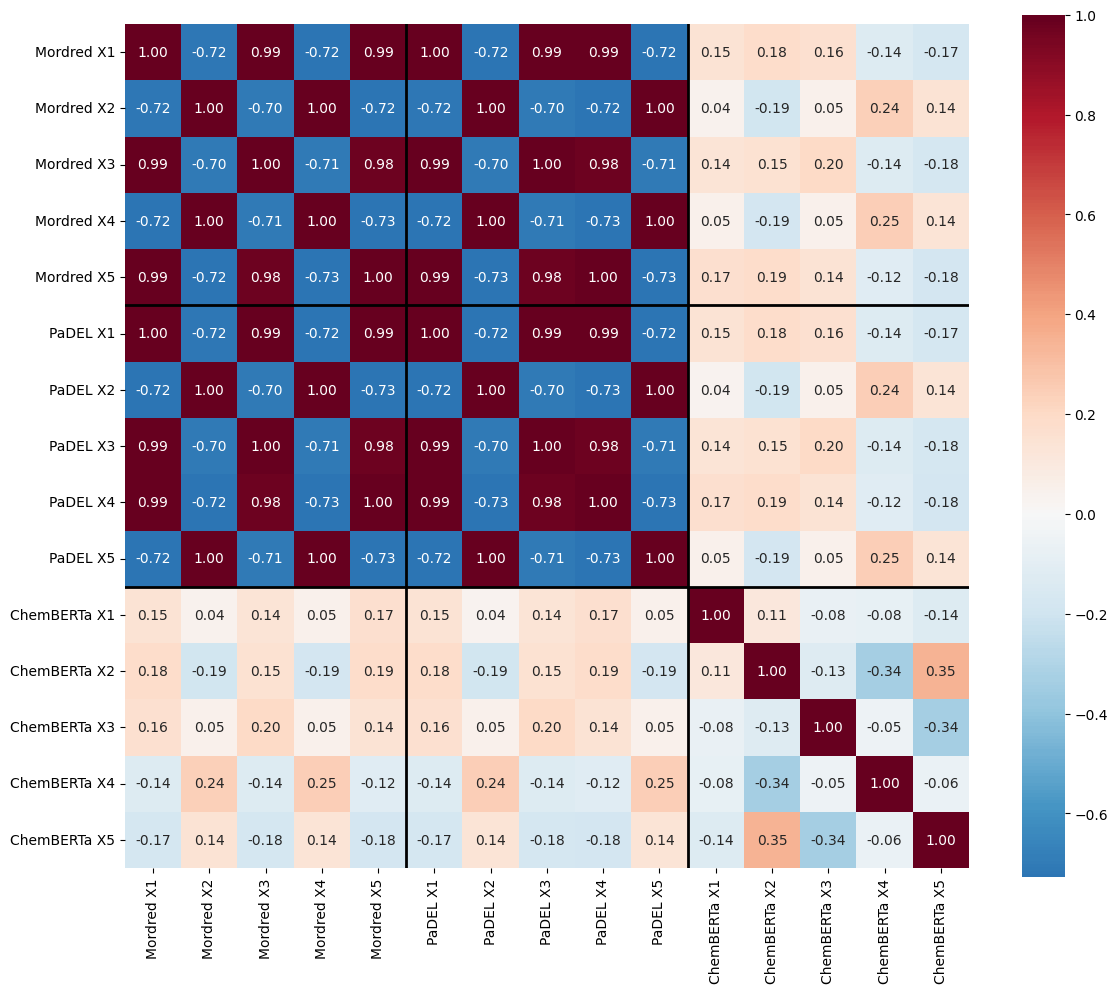

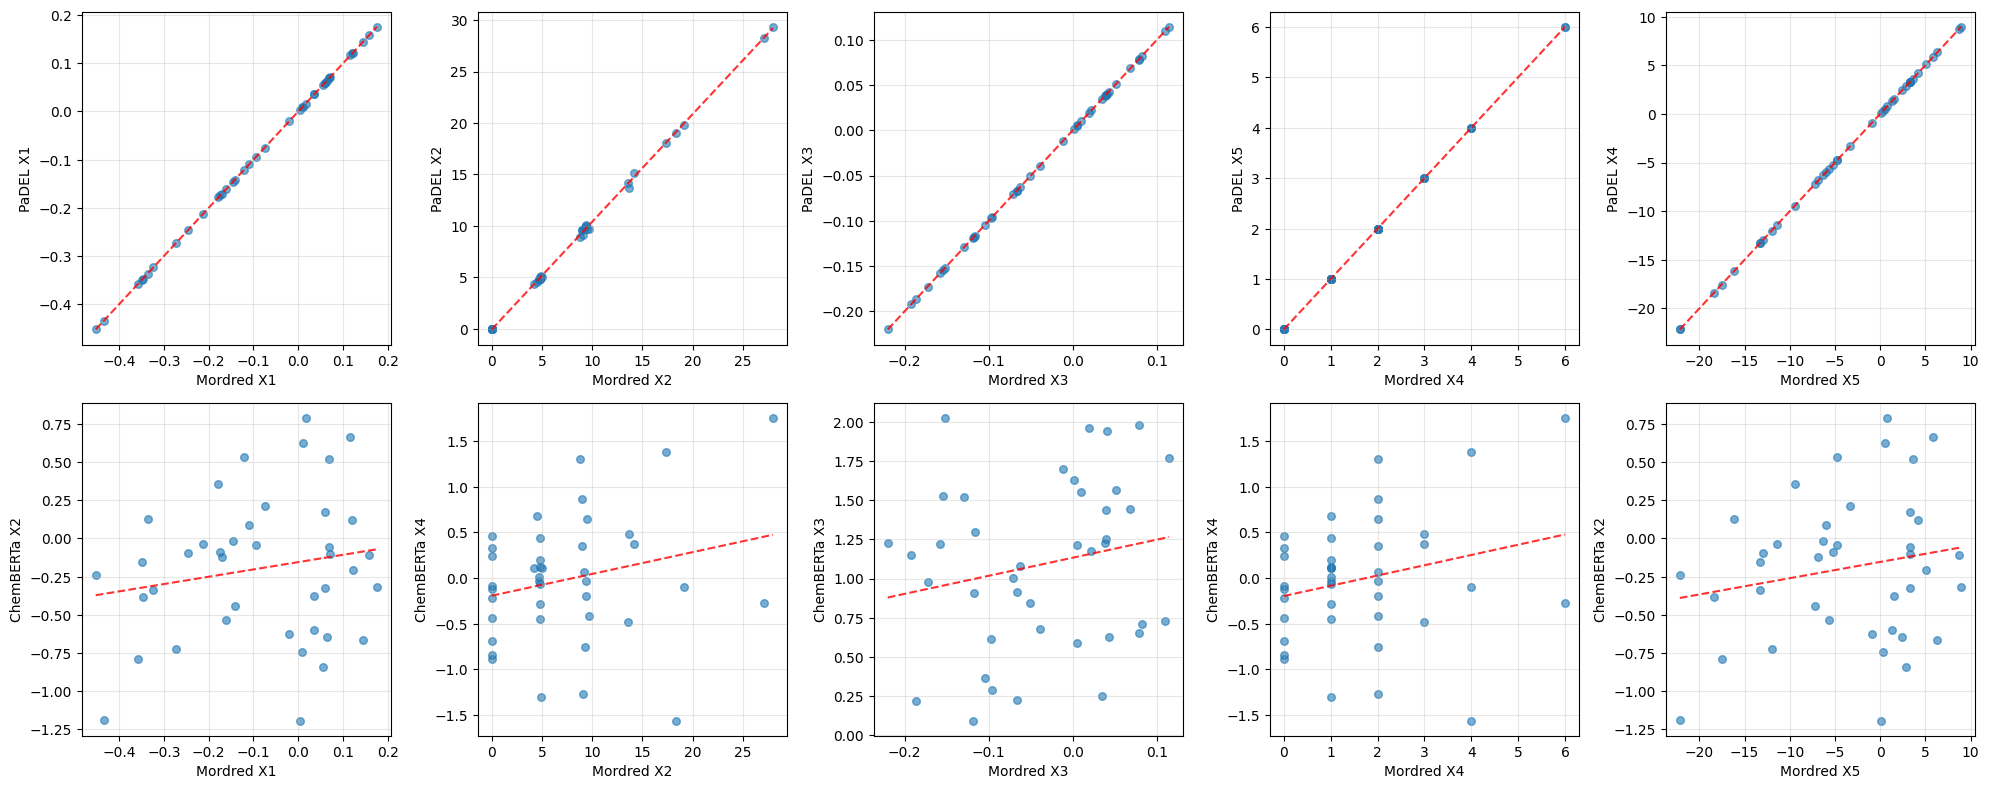


=== Best Cross-Feature Matches ===

Mordred vs PaDEL best matches:
  F1 best matches F'1: r = 1.000
  F2 best matches F'2: r = 1.000
  F3 best matches F'3: r = 1.000
  F4 best matches F'5: r = 1.000
  F5 best matches F'4: r = 1.000

Mordred vs ChemBERTa best matches:
  F1 best matches F'2: r = 0.179
  F2 best matches F'4: r = 0.243
  F3 best matches F'3: r = 0.199
  F4 best matches F'4: r = 0.250
  F5 best matches F'2: r = 0.190


In [36]:
analyze_feature_correlations(X_sub,labels=names)


# prediction accuracy

In [14]:

from UQtools import get_slope_metric, spearman_rank_corr, calibration_curve, calibration_area, NLL
from UQtools import order_sig_and_errors, get_slope_metric, spearman_rank_corr, expected_rho, calibration_curve, calibration_area, plot_calibration_curve, plot_Z_scores, NLL


def get_UQ(target, pred, std):
  df = pd.DataFrame()
  df['target']  = target
  df['uq']      = std
  df['y_pred']  = pred
  df['error']   = pred - target

  #Order uncertainties and errors according to uncertainties
  ordered_df = order_sig_and_errors(df.uq, df.error)

  #calculate rho_rank
  rho_rank, _ = spearman_rank_corr(np.abs(df.error), df.uq)
  print(f'rho_rank = {rho_rank:.2f}')

  #Calculate the miscalibration area
  gaus_pred, errors_observed = calibration_curve(ordered_df.abs_z)
  mis_cal = calibration_area(errors_observed, gaus_pred)
  print(f'miscalibration area = {mis_cal:.2f}')


  #generate error-based calibration plot
  #fig, slope, R_sq, intercept = get_slope_metric(ordered_df.uq, ordered_df.errors, Nbins=25)
  #del fig
  return mis_cal

In [15]:
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll as fit_gpytorch_model
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.models.transforms import Normalize, Standardize
import gpytorch
from gpytorch.kernels import MaternKernel, ScaleKernel

def train_test_GP(X_train, y_train, X_test, y_test, calc, target):
    # Ensure inputs are torch tensors with correct shape
    X_train = torch.tensor(X_train, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1)
    X_test = torch.tensor(X_test, dtype=torch.float32)
    y_test = torch.tensor(y_test, dtype=torch.float32)

    # Train SingleTaskGP
    model = SingleTaskGP(X_train,y_train,
                        input_transform=Normalize(X_train.shape[-1]),
                        outcome_transform=Standardize(m=1),
                         covar_module = ScaleKernel(MaternKernel(nu=2.5))
                        )
    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    fit_gpytorch_model(mll)


    # Test
    model.eval()
    with torch.no_grad():
        posterior = model.posterior(X_train)
        y_pred_ = posterior.mean.squeeze(-1).numpy()

    # Calculate R^2
    y_true = y_train.numpy()
    r2 = r2_score(y_true, y_pred_)
    print(f"train r2:{r2:.2f}")


    # Test
    model.eval()
    with torch.no_grad():
        posterior = model.posterior(X_test)
        y_pred = posterior.mean.squeeze(-1).numpy()
        y_var = posterior.variance.squeeze(-1).numpy()

    # Calculate R^2
    y_true = y_test.numpy()
    r2 = r2_score(y_true, y_pred)
    print(f"test r2:{r2:.2f}")

    uq_mis_cal = get_UQ(y_true, y_pred, y_var**0.5)

    # Parity plot
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.7, edgecolors='k')
    plt.errorbar(y_true, y_pred, yerr=y_var**0.5, fmt='none', ecolor='gray', alpha=0.3)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    plt.plot(lims, lims, 'r--', linewidth=1)
    plt.xlabel("True Values")
    plt.ylabel("Predicted Values")
    plt.title(f"Parity Plot: {target} ({calc})")
    plt.text(0.05, 0.95, f"Prediction $R^2$ = {r2:.3f}\nMis. cal.$ = {uq_mis_cal:.3f}", transform=plt.gca().transAxes,
             fontsize=12, verticalalignment='top')
    plt.tight_layout()
    plt.xlim(-250,5)
    plt.ylim(-250,5)

    Savename = f"calcComparison_{calc}_{target}.png"
    plt.savefig(Savename, dpi=300)
    plt.close()


In [ ]:
#X_sub_test[i1]#.iloc[0,1] #= X_sub_test[i1].iloc[0,1:].mean()
#X_sub_test[i1] = X_sub_test[i1].fillna(X_sub_test[i1].mean())

AttributeError: 'numpy.ndarray' object has no attribute 'fillna'

In [16]:

for i1,x in enumerate(X_sub):
  if i1 == 0 : calc = 'Mordred'
  elif i1 == 1 : calc = 'PaDEL'
  else : calc = 'ChemBERTa'


  print(prob, calc)

  try:train_test_GP(torch.tensor(X_sub[i1].to_numpy()), torch.tensor(y_train),
                    torch.tensor(X_sub_test[i1].to_numpy()), torch.tensor(y_test),
                    calc, prob)

  except: train_test_GP(torch.tensor(X_sub[i1]), torch.tensor(y_train),
                        torch.tensor(X_sub_test[i1]), torch.tensor(y_test),
                        calc, prob)



cep Mordred
train r2:0.68
test r2:0.43
rho_rank = 0.24
miscalibration area = 0.23
cep PaDEL
train r2:0.69
test r2:0.43
rho_rank = 0.24
miscalibration area = 0.22
cep ChemBERTa
train r2:0.00
test r2:-0.00
rho_rank = 0.12
miscalibration area = 0.50


# interpret


In [29]:

common = []
uncommon_mord = []
for i in X_sub[0].columns:
  if i in X_sub[1].columns:
    common.append(i)
  else:
    uncommon_mord.append(i)

uncommon_padel = []
for i in X_sub[1].columns:
  if i in X_sub[0].columns:
    continue
  else:
    uncommon_padel.append(i)

print('common: ', common)
print('Modred unique :', uncommon_mord)
print('Padel unique :', uncommon_padel)
print('\n')


common:  ['GATS1p', 'AATSC2i', 'GATS1i']
Modred unique : ['AETA_beta_s', 'AATS2s']
Padel unique : ['ETA_BetaP_s', 'PNSA-1']




In [44]:
'''
################################
Solvation Free Energy (∆Gsolv)
Contains over 103,000 quinone derivatives with the two
properties of interest (∆Gsolv and E
0
) being computed with
density functional theory. These properties are relevant to
energy storage and redox chemistry, and we use them to explore single- and multi-objective optimization scenarios.

Shared
GATS1p      : geary coefficient of lag 1 weighted by polarizability
AATSC2i     : averaged and centered moreau-broto autocorrelation of lag 2 weighted by ionization potential
GATS1i      : geary coefficient of lag 1 weighted by ionization potential


Mord. unique
AETA_beta_s : averaged sigma contribution to valence electron mobile count
AATS2s      : averaged moreau-broto autocorrelation of lag 2 weighted by intrinsic state

Padel unique
ETA_BetaP_s : A measure of electronegative atom count of the molecule relative to molecular size
PNSA-1      : Partial negative surface area -- sum of surface area on negative parts of molecule

################################



################################

Power Conversion Efficiency (PCE) 75: Contains 29,978 organic photovoltaic
molecules with computed PCE values,representing the efficiency of
solar-to-electric energy conversion. This dataset serves as a proxy for
high-throughput materials discovery in renewable energy applications.

Shared
AATSC1i : averaged and centered moreau-broto autocorrelation of lag 1 weighted by ionization potential
MATS1i  : moran coefficient of lag 1 weighted by ionization potential
ATSC1i  : centered moreau-broto autocorrelation of lag 1 weighted by ionization potential


Mord. unique
SaaN    : Sum of atom-type E-state indices for nitrogen atoms (total electrotopological state contribution from nitrogen atoms)
NaaN    : Number of nitrogen atoms in aromatic rings (count of aromatic nitrogen atoms)

Padel unique
SdsN    : Sum of atom-type E-state indices for nitrogen atoms in double bonds (electrotopological state contribution from doubly-bonded nitrogen)
ndsN    : Number of nitrogen atoms in double bonds (count of nitrogen atoms participating in double bond formation)

################################






'''

'\n################################\n\nGibbs free energy of solvation - shared\nGATS1p      : geary coefficient of lag 1 weighted by polarizability\nAATSC2i     : averaged and centered moreau-broto autocorrelation of lag 2 weighted by ionization potential\nGATS1i      : geary coefficient of lag 1 weighted by ionization potential\n\n\nMord. unique\nAETA_beta_s : averaged sigma contribution to valence electron mobile count\nAATS2s      : averaged moreau-broto autocorrelation of lag 2 weighted by intrinsic state\n\nPadel unique\nETA_BetaP_s : A measure of electronegative atom count of the molecule relative to molecular size\nPNSA-1      : Partial negative surface area -- sum of surface area on negative parts of molecule\n\n################################\n\n\n\n################################\n\nxxx - shared\n\n\n\nMord. unique\n\n\nPadel unique\n\n\n################################\n\n\n\n\n\n\n'